# Evaluation: Solution Quality vs Runtime

In [1]:
import sys
sys.path.append('src')

import time
import pandas as pd
import matplotlib.pyplot as plt

from vrptw import generate_vrptw_instance, solution_total_distance
from greedy import greedy_construction
from local_search import local_search

print("Imports successful")

Imports successful


## Compare Across Instance Sizes

In [2]:
sizes = [10, 20, 50, 100]
results = []

for n in sizes:
    instance = generate_vrptw_instance(n_customers=n, vehicle_capacity=100, num_vehicles=max(5, n // 4))

    t0 = time.perf_counter()
    greedy_routes, unserved = greedy_construction(instance)
    greedy_time = time.perf_counter() - t0
    greedy_dist = solution_total_distance(greedy_routes, instance)

    t0 = time.perf_counter()
    improved_routes = local_search(greedy_routes, instance)
    ls_time = time.perf_counter() - t0
    improved_dist = solution_total_distance(improved_routes, instance)

    results.append({
        "n_customers": n,
        "Greedy_distance": greedy_dist,
        "Greedy_time_ms": greedy_time * 1000,
        "Greedy_unserved": len(unserved),
        "LocalSearch_distance": improved_dist,
        "LocalSearch_time_ms": (greedy_time + ls_time) * 1000,  # total pipeline time
        "Improvement_%": (1 - improved_dist / greedy_dist) * 100 if greedy_dist else None,
    })
    print(f"Completed n={n}")

df_eval = pd.DataFrame(results)
df_eval

Completed n=10
Completed n=20
Completed n=50
Completed n=100


,n_customers,Greedy_distance,Greedy_time_ms,Greedy_unserved,LocalSearch_distance,LocalSearch_time_ms,Improvement_%
0,10,417.756722,0.059625,0,396.545529,1.921125,5.077403
1,20,757.765880,0.086792,0,571.353589,17.609626,24.600249
2,50,1543.007771,0.447667,0,1235.516504,123.415792,19.928044
3,100,2947.536282,0.683667,0,2420.030515,513.606459,17.896498


## Visualizing Quality vs Runtime Trade-off

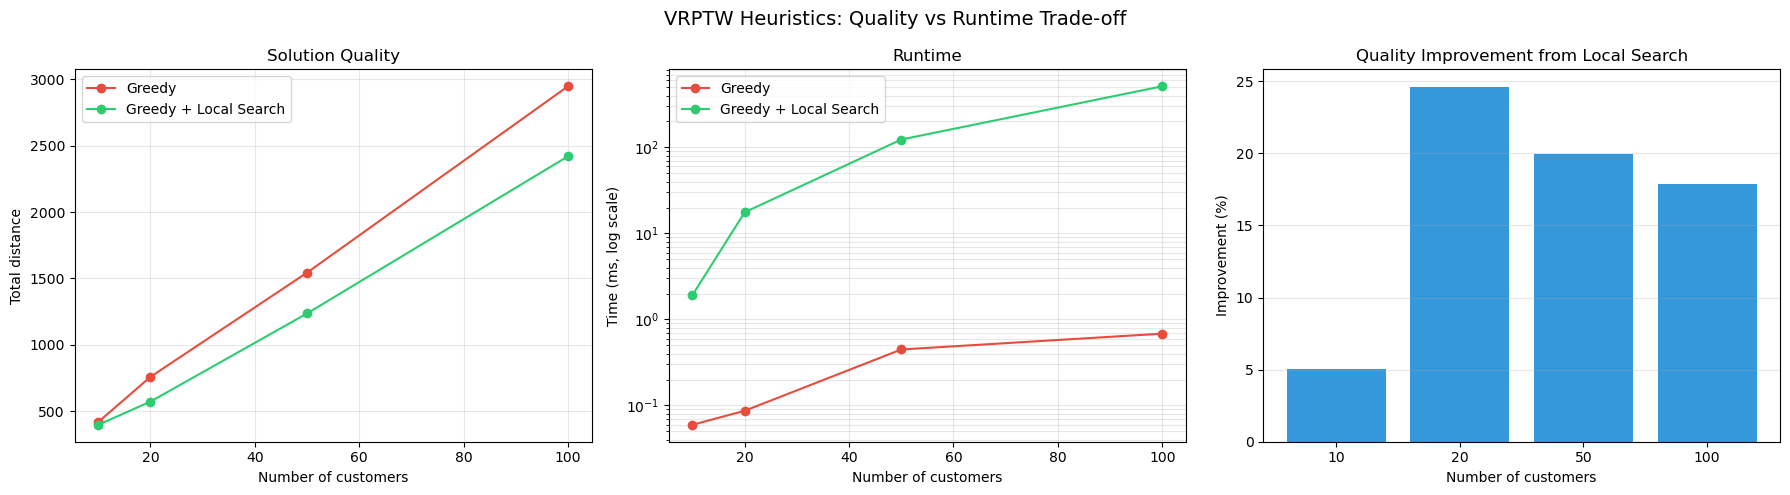

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: solution quality comparison
axes[0].plot(df_eval["n_customers"], df_eval["Greedy_distance"], marker='o', label="Greedy", color='#e74c3c')
axes[0].plot(df_eval["n_customers"], df_eval["LocalSearch_distance"], marker='o', label="Greedy + Local Search", color='#2ecc71')
axes[0].set_xlabel("Number of customers")
axes[0].set_ylabel("Total distance")
axes[0].set_title("Solution Quality")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: runtime comparison (log scale, since local search grows much faster)
axes[1].plot(df_eval["n_customers"], df_eval["Greedy_time_ms"], marker='o', label="Greedy", color='#e74c3c')
axes[1].plot(df_eval["n_customers"], df_eval["LocalSearch_time_ms"], marker='o', label="Greedy + Local Search", color='#2ecc71')
axes[1].set_yscale('log')
axes[1].set_xlabel("Number of customers")
axes[1].set_ylabel("Time (ms, log scale)")
axes[1].set_title("Runtime")
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

# Panel 3: improvement % vs instance size
axes[2].bar(df_eval["n_customers"].astype(str), df_eval["Improvement_%"], color='#3498db')
axes[2].set_xlabel("Number of customers")
axes[2].set_ylabel("Improvement (%)")
axes[2].set_title("Quality Improvement from Local Search")
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle("VRPTW Heuristics: Quality vs Runtime Trade-off", fontsize=14)
plt.tight_layout()
plt.show()